In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Dataset Source: https://www.kaggle.com/datasets/lodetomasi1995/income-classification

Informasi:
- Dataset yang digunakan untuk latihan gunakan hasil dari Question Creation dibawah.

# **Question Creation**

In [2]:
url = 'income_evaluation_dataset.csv'
df = pd.read_csv(url,
                  sep=',',
                  encoding='latin-1',  # or encoding='ISO-8859-1'
                  parse_dates=[0])

C:\Users\kanek\AppData\Local\Temp\ipykernel_34612\2363813017.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(url,


In [3]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              32561 non-null  object
 1    workclass       32561 non-null  object
 2    fnlwgt          32561 non-null  int64 
 3    education       32561 non-null  object
 4    education-num   32561 non-null  int64 
 5    marital-status  32561 non-null  object
 6    occupation      32561 non-null  object
 7    relationship    32561 non-null  object
 8    race            32561 non-null  object
 9    sex             32561 non-null  object
 10   capital-gain    32561 non-null  int64 
 11   capital-loss    32561 non-null  int64 
 12   hours-per-week  32561 non-null  int64 
 13   native-country  32561 non-null  object
 14   income          32561 non-null  object
dtypes: int64(5), object(10)
memory usage: 3.7+ MB


In [5]:
# Mengganti nama kolom dan menghapus spasi
df.columns = df.columns.str.replace(' ', '')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  object
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(5), object(10)
memory usage: 3.7+ MB


In [6]:
print("Nilai fnlwgt : ",df['fnlwgt'].max())
print("Nilai fnlwgt : ",df['fnlwgt'].min())

Nilai fnlwgt :  1484705
Nilai fnlwgt :  12285


In [7]:
jumlah_kelas = 10
rentang_data = (df['fnlwgt'].min(), df['fnlwgt'].max())
bins = np.linspace(rentang_data[0], rentang_data[1], jumlah_kelas + 1)
labels = ['exceptionally low', 'exceedingly low', 'subdued', 'somewhat low', 'medium', 'somewhat high', 'elevated', 'highly elevated', 'exceptionally high', 'ultra-high']

# Gunakan pd.cut untuk membagi data menjadi kategori
df['fnlwgt'] = pd.cut(df['fnlwgt'], bins=bins, labels=labels, include_lowest=True)

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,exceptionally low,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,exceptionally low,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,exceedingly low,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,exceedingly low,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,subdued,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [8]:
df['fnlwgt'].value_counts()

fnlwgt
exceedingly low       15327
exceptionally low     13117
subdued                3498
somewhat low            477
medium                  102
somewhat high            20
elevated                 10
highly elevated           5
ultra-high                3
exceptionally high        2
Name: count, dtype: int64

In [9]:
df['education-num'].value_counts()

education-num
9     10501
10     7291
13     5355
14     1723
11     1382
7      1175
12     1067
6       933
4       646
15      576
5       514
8       433
16      413
3       333
2       168
1        51
Name: count, dtype: int64

In [10]:
df['income'].value_counts()

income
 <=50K    24720
 >50K      7841
Name: count, dtype: int64

In [11]:
df['hours-per-week'].value_counts()

hours-per-week
40    15217
50     2819
45     1824
60     1475
35     1297
      ...  
82        1
92        1
87        1
74        1
94        1
Name: count, Length: 94, dtype: int64

In [12]:
df.tail()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
32556,27,Private,exceedingly low,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,exceptionally low,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,exceptionally low,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,exceedingly low,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,exceedingly low,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


In [13]:
jumlah_kelas = 10
rentang_data = (df['hours-per-week'].min(), df['hours-per-week'].max())
bins = np.linspace(rentang_data[0], rentang_data[1], jumlah_kelas + 1)
labels = ['exceptionally low', 'exceedingly low', 'subdued', 'somewhat low', 'medium', 'somewhat high', 'elevated', 'highly elevated', 'exceptionally high', 'ultra-high']

# Gunakan pd.cut untuk membagi data menjadi kategori
df['hours-per-week'] = pd.cut(df['hours-per-week'], bins=bins, labels=labels, include_lowest=True)

In [14]:
df.tail()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
32556,27,Private,exceedingly low,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,somewhat low,United-States,<=50K
32557,40,Private,exceptionally low,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,somewhat low,United-States,>50K
32558,58,Private,exceptionally low,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,somewhat low,United-States,<=50K
32559,22,Private,exceedingly low,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,exceedingly low,United-States,<=50K
32560,52,Self-emp-inc,exceedingly low,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,somewhat low,United-States,>50K


# **Perhatikan:**

Saya memodifikasi feature **fnlwgt** dan **hours-per-week** menjadi data kategorikal yang nilainya memperhatikan rating, sehingga kita tidak bisa melakukan label encoding dengan cara biasa. Label encoding harus dilakukan secara memperhatikan urutannya seperti digambar dibawah:


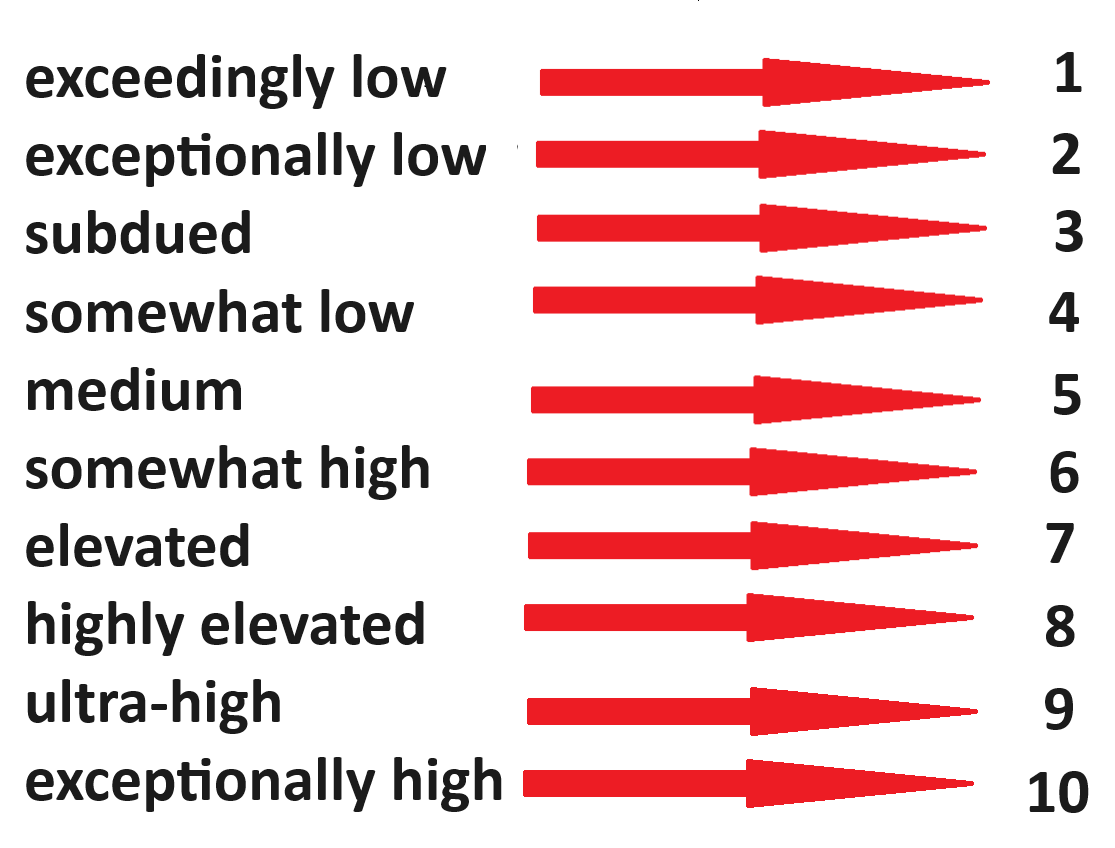

# **1. Classification**

In [104]:
df_classification = df
df_classification.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,exceptionally low,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,somewhat low,United-States,<=50K
1,50,Self-emp-not-inc,exceptionally low,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,exceedingly low,United-States,<=50K
2,38,Private,exceedingly low,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,somewhat low,United-States,<=50K
3,53,Private,exceedingly low,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,somewhat low,United-States,<=50K
4,28,Private,subdued,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,somewhat low,Cuba,<=50K


Task (Mencoba alur split data terlebih dahulu kemudian preprocessing(handling missing value and feature engineering)):
1. Lakukan Split Dataset.
2. Lakukan preprocessing pada data training.
3. Lakukan preprocessing pada data testing.
4. Coba berbagai kernel pada model SVM.
5. Coba gunakan berbagai model ensemble learning dengan ketentuan 2 model bagging, 2 model boosting, dan 2 model stacking
6. Buat satu buah Table yang menampung semua perbanding hasil testing dengan model berbagai model.

In [105]:
# Set age as numeric
df_classification['age'] = pd.to_numeric(df_classification['age'])

In [106]:
# Get unique Values of all categorical column

object_col = list()

for col in df_classification :
    if not pd.api.types.is_numeric_dtype(df_classification[col]) :
        object_col.append(col)

object_col

['workclass',
 'fnlwgt',
 'education',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'hours-per-week',
 'native-country',
 'income']

In [107]:
df_classification['workclass'].unique()

array([' State-gov', ' Self-emp-not-inc', ' Private', ' Federal-gov',
       ' Local-gov', ' ?', ' Self-emp-inc', ' Without-pay',
       ' Never-worked'], dtype=object)

In [108]:
# Make a dataframe of all unique values for all object features
object_unique = pd.DataFrame()

for col in object_col :
    unique_list = list()
    for val in df_classification[col].unique() :
        unique_list.append(val)
    object_unique[col] = pd.Series(unique_list)

object_unique

,workclass,fnlwgt,education,marital-status,occupation,relationship,race,sex,hours-per-week,native-country,income
0,State-gov,exceptionally low,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,somewhat low,United-States,<=50K
1,Self-emp-not-inc,exceedingly low,HS-grad,Married-civ-spouse,Exec-managerial,Husband,Black,Female,exceedingly low,Cuba,>50K
2,Private,subdued,11th,Divorced,Handlers-cleaners,Wife,Asian-Pac-Islander,NaN,medium,Jamaica,NaN
3,Federal-gov,somewhat low,Masters,Married-spouse-absent,Prof-specialty,Own-child,Amer-Indian-Eskimo,NaN,exceptionally high,India,NaN
4,Local-gov,medium,9th,Separated,Other-service,Unmarried,Other,NaN,subdued,?,NaN
5,?,somewhat high,Some-college,Married-AF-spouse,Sales,Other-relative,NaN,NaN,elevated,Mexico,NaN
6,Self-emp-inc,elevated,Assoc-acdm,Widowed,Craft-repair,NaN,NaN,NaN,somewhat high,South,NaN
7,Without-pay,highly elevated,Assoc-voc,NaN,Transport-moving,NaN,NaN,NaN,highly elevated,Puerto-Rico,NaN
8,Never-worked,exceptionally high,7th-8th,NaN,Farming-fishing,NaN,NaN,NaN,exceptionally low,Honduras,NaN


In [109]:
# set all '?' as missing value
df_classification.replace(' ?', np.nan, inplace=True)

In [110]:
df_classification.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

In [111]:
# Data Missing Value Cleaner FUnction

def missing_clean(data) :
    for col in data :
        if data[col].isnull().sum() > 0 :
            if pd.api.types.is_numeric_dtype(data[col]) :
                data[col].fillna(data[col].mean(), inplace=True)
            else :
                data[col].fillna(data[col].mode()[0], inplace=True)

## 1. Split Dataset

In [125]:
from sklearn.model_selection import train_test_split

X = df_classification.drop('income', axis=1)
Y = df_classification['income']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=25)

## 2. Data Train Preprocessing

### Check Dataframe

In [126]:
x_train.isnull().sum()

age                  0
workclass         1452
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1459
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     476
dtype: int64

In [127]:
x_train.dtypes

age                  int64
workclass           object
fnlwgt            category
education           object
education-num        int64
marital-status      object
occupation          object
relationship        object
race                object
sex                 object
capital-gain         int64
capital-loss         int64
hours-per-week    category
native-country      object
dtype: object

### Data Cleaning

In [128]:
# Clean Missing Value
missing_clean(x_train)

In [129]:
x_train.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
dtype: int64

### Encoding for non-Hierirchical Categorical Data

In [130]:
object_col_train = list()
for col in x_train :
    object_col_train.append(col)
object_col_train.remove('fnlwgt')
object_col_train.remove('hours-per-week')
object_col_train

['age',
 'workclass',
 'education',
 'education-num',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'capital-gain',
 'capital-loss',
 'native-country']

In [131]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

x_train[object_col_train] = encoder.fit_transform(x_train[object_col_train])

In [132]:
x_train

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
22625,8.0,3.0,subdued,9.0,12.0,4.0,3.0,1.0,2.0,0.0,0.0,0.0,somewhat low,38.0
13390,40.0,3.0,exceedingly low,9.0,12.0,2.0,9.0,0.0,4.0,1.0,50.0,0.0,medium,38.0
24467,10.0,3.0,exceedingly low,8.0,10.0,4.0,3.0,3.0,4.0,1.0,0.0,0.0,somewhat low,38.0
21022,9.0,5.0,exceedingly low,9.0,12.0,0.0,11.0,1.0,4.0,1.0,0.0,0.0,somewhat low,38.0
941,18.0,3.0,somewhat low,11.0,8.0,2.0,6.0,0.0,2.0,1.0,0.0,0.0,somewhat low,38.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32061,42.0,3.0,subdued,10.0,15.0,2.0,9.0,0.0,4.0,1.0,0.0,0.0,medium,38.0
26767,36.0,5.0,exceedingly low,0.0,5.0,2.0,4.0,0.0,4.0,1.0,0.0,0.0,somewhat low,38.0
6618,10.0,3.0,subdued,11.0,8.0,2.0,13.0,0.0,4.0,1.0,0.0,0.0,ultra-high,38.0
24894,45.0,3.0,exceptionally low,12.0,13.0,2.0,3.0,0.0,4.0,1.0,0.0,0.0,subdued,38.0


### Encoding for Hierirchical Categorical Data

In [133]:
labels

['exceptionally low',
 'exceedingly low',
 'subdued',
 'somewhat low',
 'medium',
 'somewhat high',
 'elevated',
 'highly elevated',
 'exceptionally high',
 'ultra-high']

In [134]:
# Make fnlwgt and hours-per-week as numeric based on labels
x_train['fnlwgt'] = x_train['fnlwgt'].map({labels[i] : i for i in range(len(labels))})
x_train['hours-per-week'] = x_train['hours-per-week'].map({labels[i] : i for i in range(len(labels))})
x_train

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
22625,8.0,3.0,2,9.0,12.0,4.0,3.0,1.0,2.0,0.0,0.0,0.0,3,38.0
13390,40.0,3.0,1,9.0,12.0,2.0,9.0,0.0,4.0,1.0,50.0,0.0,4,38.0
24467,10.0,3.0,1,8.0,10.0,4.0,3.0,3.0,4.0,1.0,0.0,0.0,3,38.0
21022,9.0,5.0,1,9.0,12.0,0.0,11.0,1.0,4.0,1.0,0.0,0.0,3,38.0
941,18.0,3.0,3,11.0,8.0,2.0,6.0,0.0,2.0,1.0,0.0,0.0,3,38.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32061,42.0,3.0,2,10.0,15.0,2.0,9.0,0.0,4.0,1.0,0.0,0.0,4,38.0
26767,36.0,5.0,1,0.0,5.0,2.0,4.0,0.0,4.0,1.0,0.0,0.0,3,38.0
6618,10.0,3.0,2,11.0,8.0,2.0,13.0,0.0,4.0,1.0,0.0,0.0,9,38.0
24894,45.0,3.0,0,12.0,13.0,2.0,3.0,0.0,4.0,1.0,0.0,0.0,2,38.0


## 3. Test Data Preprocessing

### Check Dataframe

In [122]:
x_test.isnull().sum()

age                 0
workclass         384
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        384
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    107
dtype: int64

### Encoding for non-Hierirchical Categorical Data

In [135]:
x_test[object_col_train] = encoder.transform(x_test[object_col_train])

### Encoding for Hierirchical Categorical Data

In [136]:
x_test['fnlwgt'] = x_test['fnlwgt'].map({labels[i] : i for i in range(len(labels))})
x_test['hours-per-week'] = x_test['hours-per-week'].map({labels[i] : i for i in range(len(labels))})
x_test

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
3254,32.0,5.0,1,11.0,8.0,2.0,2.0,0.0,4.0,1.0,0.0,0.0,3,38.0
30026,0.0,3.0,1,1.0,6.0,4.0,7.0,2.0,4.0,0.0,0.0,0.0,2,38.0
7221,5.0,3.0,0,11.0,8.0,4.0,12.0,1.0,4.0,0.0,0.0,0.0,3,38.0
23481,6.0,3.0,1,11.0,8.0,5.0,2.0,3.0,4.0,1.0,0.0,0.0,5,38.0
15318,21.0,3.0,0,9.0,12.0,2.0,3.0,0.0,4.0,1.0,93.0,0.0,5,38.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27214,13.0,3.0,0,9.0,12.0,2.0,2.0,0.0,1.0,1.0,0.0,0.0,3,39.0
10495,12.0,3.0,2,6.0,4.0,2.0,2.0,0.0,4.0,1.0,0.0,0.0,3,38.0
6109,24.0,3.0,2,7.0,11.0,2.0,6.0,0.0,4.0,1.0,0.0,0.0,3,38.0
16160,45.0,0.0,1,11.0,8.0,6.0,0.0,4.0,4.0,0.0,0.0,0.0,3,38.0


### Data Cleaning

In [138]:
missing_clean(x_test)
x_test.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
dtype: int64

## 4. SVM Model

In [139]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV 
  
# defining parameter range 
param_grid = {'kernel': ['linear', 'poly', 'rbf']}  
  
grid = GridSearchCV(SVC(), param_grid, scoring='accuracy') 

grid.fit(x_train, y_train)

GridSearchCV(estimator=SVC(), param_grid={'kernel': ['linear', 'poly', 'rbf']},
             scoring='accuracy')

In [140]:
# print best parameter after tuning 
print(grid.best_params_) 
  
# print how our model looks after hyper-parameter tuning 
print(grid.best_estimator_) 

{'kernel': 'poly'}
SVC(kernel='poly')


## 5. Ensemble Learning Model

### 5.1A Bagging Model Default

In [141]:
from sklearn.ensemble import BaggingClassifier

bag_class = BaggingClassifier(random_state=25)
bag_class.fit(x_train, y_train)

BaggingClassifier(random_state=25)

In [142]:
bag_pred = bag_class.predict(x_test)

In [143]:
from sklearn.metrics import classification_report

print('Classification Report')
print(classification_report(y_test, bag_pred))

Classification Report
              precision    recall  f1-score   support

       <=50K       0.89      0.91      0.90      5000
        >50K       0.67      0.62      0.64      1513

    accuracy                           0.84      6513
   macro avg       0.78      0.76      0.77      6513
weighted avg       0.84      0.84      0.84      6513



### 5.1B Bagging Model Decision Tree

In [144]:
from sklearn.tree import DecisionTreeClassifier

dt_bag = BaggingClassifier(estimator=DecisionTreeClassifier(), random_state=25)
dt_bag.fit(x_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), random_state=25)

In [145]:
dt_bag_pred = dt_bag.predict(x_test)

In [146]:
from sklearn.metrics import classification_report

print('Classification Report')
print(classification_report(y_test, dt_bag_pred))

Classification Report
              precision    recall  f1-score   support

       <=50K       0.89      0.91      0.90      5000
        >50K       0.67      0.62      0.64      1513

    accuracy                           0.84      6513
   macro avg       0.78      0.76      0.77      6513
weighted avg       0.84      0.84      0.84      6513



### 5.2A Boosting Model Default

In [147]:
from sklearn.ensemble import AdaBoostClassifier

boost_class = AdaBoostClassifier(random_state=25)
boost_class.fit(x_train, y_train)

AdaBoostClassifier(random_state=25)

In [148]:
boost_pred = boost_class.predict(x_test)

In [149]:
from sklearn.metrics import classification_report

print('Classification Report')
print(classification_report(y_test, boost_pred))

Classification Report
              precision    recall  f1-score   support

       <=50K       0.89      0.94      0.91      5000
        >50K       0.75      0.61      0.67      1513

    accuracy                           0.86      6513
   macro avg       0.82      0.77      0.79      6513
weighted avg       0.86      0.86      0.86      6513



### 5.2B Boosting Model Decision Tree

In [150]:
dt_boost = AdaBoostClassifier(estimator=DecisionTreeClassifier(), random_state=25)
dt_boost.fit(x_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(), random_state=25)

In [151]:
dt_boost_pred = dt_boost.predict(x_test)

In [152]:
from sklearn.metrics import classification_report

print('Classification Report')
print(classification_report(y_test, dt_boost_pred))

Classification Report
              precision    recall  f1-score   support

       <=50K       0.89      0.90      0.89      5000
        >50K       0.66      0.62      0.64      1513

    accuracy                           0.84      6513
   macro avg       0.77      0.76      0.77      6513
weighted avg       0.83      0.84      0.84      6513



### 5.3A Stacking Model Default

Contoh Table:


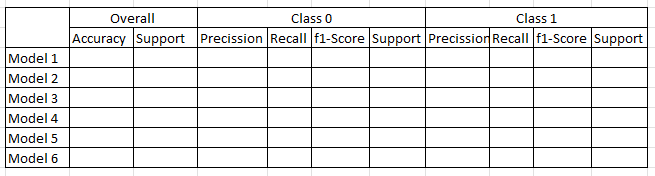

# **2. Clustering**

In [15]:
df_clustering = df.drop(['income'], axis=1)
df_clustering.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,exceptionally low,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,somewhat low,United-States
1,50,Self-emp-not-inc,exceptionally low,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,exceedingly low,United-States
2,38,Private,exceedingly low,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,somewhat low,United-States
3,53,Private,exceedingly low,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,somewhat low,United-States
4,28,Private,subdued,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,somewhat low,Cuba


Task:
1. Lakukan Feature Engineering
2. Coba 3 model Clustering seperti KMeans, DBSCAN, dan Hierarchical Clustering.
3. Pilih 3 feature sembarang atau yang ingin kalian gali informasinya lalu tampilkan perbedaan hasil dari 3 clustering model tersebut.


## 1. Feature Engineering

### Non-Hierarchical Categorical Data

In [19]:
object_col = list()

for col in df_clustering :
    if not pd.api.types.is_numeric_dtype(df_clustering[col]) :
        object_col.append(col)

object_col_train = list()
for col in object_col :
    object_col_train.append(col)
object_col_train.remove('fnlwgt')
object_col_train.remove('hours-per-week')
object_col_train

['age',
 'workclass',
 'education',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native-country']

In [20]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

df_clustering[object_col_train] = encoder.fit_transform(df_clustering[object_col_train])

In [21]:
df_clustering.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,22.0,7.0,exceptionally low,9.0,13,4.0,1.0,1.0,4.0,1.0,2174,0,somewhat low,39.0
1,33.0,6.0,exceptionally low,9.0,13,2.0,4.0,0.0,4.0,1.0,0,0,exceedingly low,39.0
2,21.0,4.0,exceedingly low,11.0,9,0.0,6.0,1.0,4.0,1.0,0,0,somewhat low,39.0
3,36.0,4.0,exceedingly low,1.0,7,2.0,6.0,0.0,2.0,1.0,0,0,somewhat low,39.0
4,11.0,4.0,subdued,9.0,13,2.0,10.0,5.0,2.0,0.0,0,0,somewhat low,5.0


### Hierarchical Categorical Data

In [22]:
df_clustering['fnlwgt'] = df_clustering['fnlwgt'].map({labels[i] : i for i in range(len(labels))})
df_clustering['hours-per-week'] = df_clustering['hours-per-week'].map({labels[i] : i for i in range(len(labels))})
df_clustering.head()


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,22.0,7.0,0,9.0,13,4.0,1.0,1.0,4.0,1.0,2174,0,3,39.0
1,33.0,6.0,0,9.0,13,2.0,4.0,0.0,4.0,1.0,0,0,1,39.0
2,21.0,4.0,1,11.0,9,0.0,6.0,1.0,4.0,1.0,0,0,3,39.0
3,36.0,4.0,1,1.0,7,2.0,6.0,0.0,2.0,1.0,0,0,3,39.0
4,11.0,4.0,2,9.0,13,2.0,10.0,5.0,2.0,0.0,0,0,3,5.0


### Data Cleaning

In [23]:
df_clustering.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
dtype: int64

In [24]:
df_clustering['workclass'].replace(np.nan, -1, inplace=True)
df_clustering['occupation'].replace(np.nan, -1, inplace=True)
df_clustering['native-country'].replace(np.nan, -1, inplace=True)
df_clustering.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
dtype: int64

## 2. Modelling

### 2.1 KMeans

In [27]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sse = [] #SUM OF SQUARED ERROR
sil = [] #SILHOUETTE SCORE
for k in range(2,11):
    km = KMeans(n_clusters=k, random_state=2)
    km_pred = km.fit_predict(df_clustering)
    sil.append(silhouette_score(df_clustering, km_pred))
    sse.append(km.inertia_)

C:\Users\kanek\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


C:\Users\kanek\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\kanek\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\kanek\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\kanek\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The defa

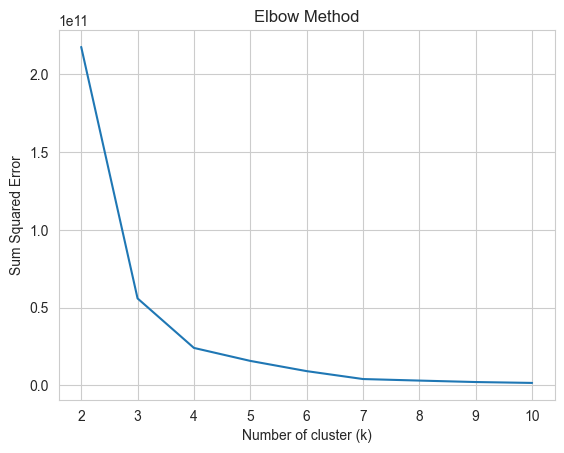

In [30]:
import seaborn as sns

sns.set_style("whitegrid")
g=sns.lineplot(x=range(2,11), y=sse)
 
g.set(xlabel ="Number of cluster (k)", 
      ylabel = "Sum Squared Error", 
      title ='Elbow Method')
 
plt.show()

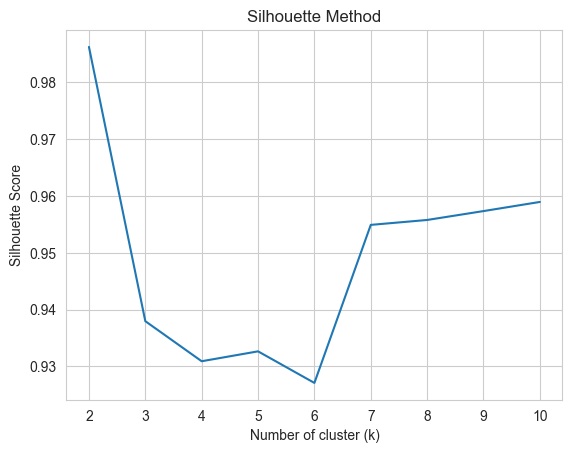

In [31]:
import seaborn as sns

sns.set_style("whitegrid")
g=sns.lineplot(x=range(2,11), y=sil)
 
g.set(xlabel ="Number of cluster (k)", 
      ylabel = "Silhouette Score", 
      title ='Silhouette Method')
 
plt.show()

In [32]:
kmeans = KMeans(n_clusters = 2, random_state = 25)
kmeans.fit(df_clustering)

C:\Users\kanek\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


KMeans(n_clusters=2, random_state=25)

In [33]:
kmeans.cluster_centers_

array([[2.15421579e+01, 3.86621196e+00, 7.49243874e-01, 1.02921733e+01,
        1.00667551e+01, 2.61443738e+00, 6.56687859e+00, 1.45043516e+00,
        3.66563792e+00, 6.68261218e-01, 5.92231436e+02, 8.77322388e+01,
        3.24563299e+00, 3.67214678e+01],
       [2.93584906e+01, 4.41509434e+00, 7.73584906e-01, 1.15283019e+01,
        1.29182390e+01, 2.08176101e+00, 7.76729560e+00, 6.16352201e-01,
        3.71069182e+00, 8.61635220e-01, 9.99990000e+04, 0.00000000e+00,
        4.32075472e+00, 3.61886792e+01]])

In [34]:
pred = kmeans.predict(df_clustering)
pred

array([0, 0, 0, ..., 0, 0, 0])

In [36]:
import plotly.express as px

px.scatter_3d(df_clustering, x='capital-gain', y='capital-loss', z='hours-per-week', color=pred)

### 2.2 DBSCAN

In [37]:
from sklearn.cluster import DBSCAN

dbs = DBSCAN(eps=1000, min_samples=5)
db_pred = dbs.fit_predict(df_clustering)

In [44]:
px.scatter(df_clustering, x='fnlwgt', y='capital-gain', color=db_pred)

### 2.3 Hierarchical Clustering

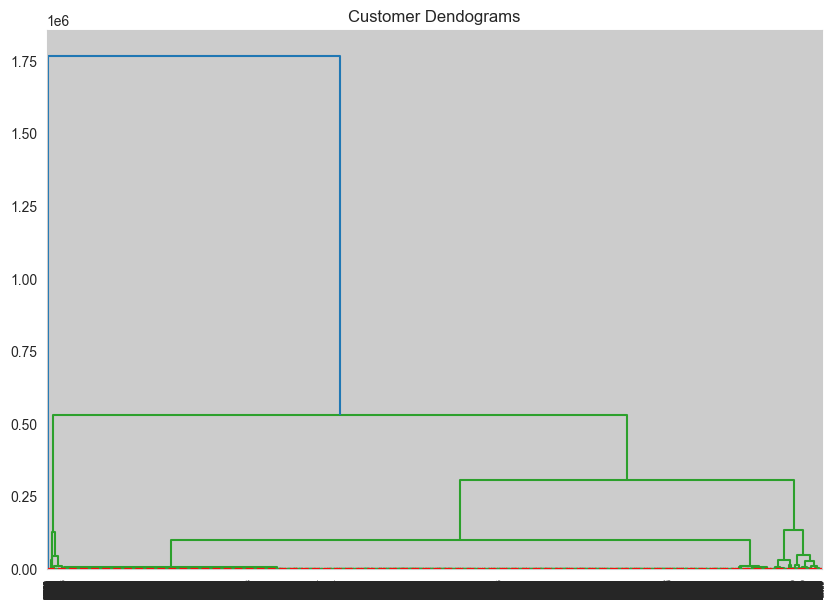

In [45]:
from scipy.cluster.hierarchy import dendrogram, linkage

plt.figure(figsize=(10, 7))
plt.title("Customer Dendograms")
dend = dendrogram(linkage(df_clustering, method='ward'))    #ward is the distance between clusters
plt.axhline(y=50, color='r', linestyle='--')
plt.show()



In [48]:
from sklearn.cluster import AgglomerativeClustering
hierarchical_cluster = AgglomerativeClustering(n_clusters=2, affinity='euclidean', linkage='ward')
labels = hierarchical_cluster.fit_predict(df_clustering)


C:\Users\kanek\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_agglomerative.py:1006: FutureWarning:

Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead



In [49]:
px.scatter(df_clustering, x='age', y='capital-gain', color=labels)